<a href="https://colab.research.google.com/github/auliaap/Analyzing-Suicidal-Ideation-Patterns-on-Twitter-Using-Association-Rule-Mining/blob/main/Project_Association_Rules_Mining_Suicidal_Ideation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The objective of this project is to transform unstructured Twitter data into actionable insights by identifying patterns of suicidal ideation through association rule mining. The analysis focuses on uncovering relationships between frequently co-occurring terms, enabling a deeper understanding of emotional and behavioral signals expressed on social media.

# **Import Library**

In [1]:
!pip install Sastrawi imbalanced-learn

import re
import json
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import warnings
warnings.filterwarnings(
    "ignore",
    message="datetime.datetime.utcnow() is deprecated"
)

nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **Collect Data**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset = '/content/drive/MyDrive/Skripsi/suicidal ideation skripsi.csv'
df = pd.read_csv(dataset, encoding='latin1')

# **Exploratory Data Analysis**

In [4]:
df.info()
df.head()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12771 entries, 0 to 12770
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Ã¯Â»Â¿conversation_id_str  12771 non-null  float64
 1   created_at                 12771 non-null  object 
 2   favorite_count             12771 non-null  int64  
 3   full_text                  12771 non-null  object 
 4   id_str                     12771 non-null  float64
 5   image_url                  460 non-null    object 
 6   in_reply_to_screen_name    5086 non-null   object 
 7   lang                       12771 non-null  object 
 8   location                   3674 non-null   object 
 9   quote_count                12771 non-null  int64  
 10  reply_count                12771 non-null  int64  
 11  retweet_count              12771 non-null  int64  
 12  tweet_url                  12771 non-null  object 
 13  user_id_str                12771 non-null  flo

(12771, 14)

**Top 10 Most Frequent Words Before Cleaning Data**

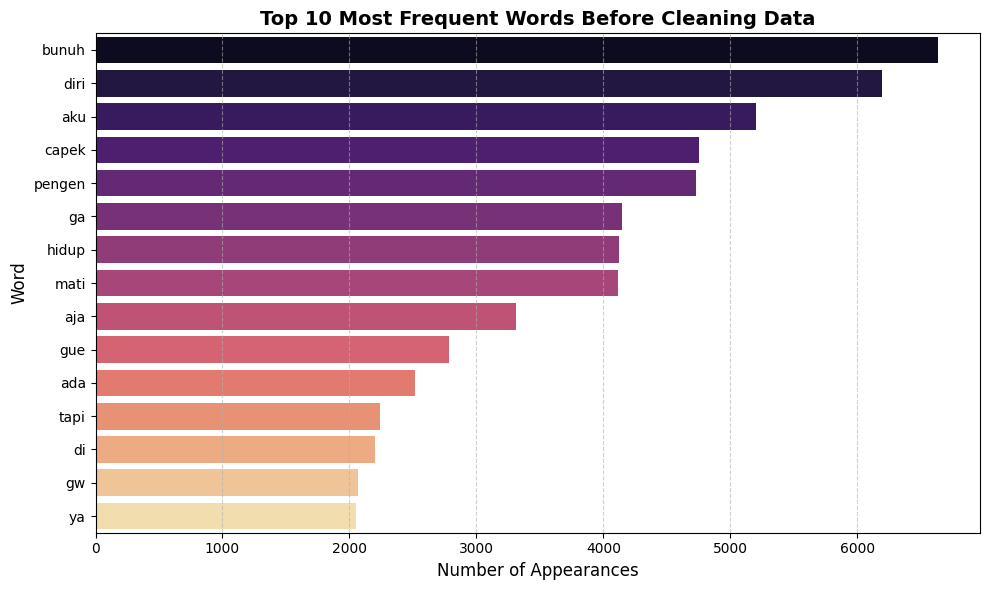

In [5]:
all_text = ' '.join(df['full_text'].astype(str)).lower()
words = all_text.split()

word_counts = Counter(words)
top_words = word_counts.most_common(15)
labels, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=list(counts),
    y=list(labels),
    hue=list(labels),
    palette='magma',
    legend=False)
plt.xlabel('Number of Appearances', fontsize=12)
plt.ylabel('Word', fontsize=12)
plt.title('Top 10 Most Frequent Words Before Cleaning Data', fontsize=14, weight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




**Post Activity by Hour**

In [6]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['created_at'] = df['created_at'].dt.tz_convert('Asia/Jakarta')

df['created_at'] = pd.to_datetime(df['created_at'])
df['hour'] = df['created_at'].dt.hour

hourly_distribution = df['hour'].value_counts().sort_index()
df_hourly = pd.DataFrame({'Hour': hourly_distribution.index, 'Tweet Count': hourly_distribution.values})

In [7]:
import plotly.express as px

fig = px.bar(df_hourly,
             x='Hour',
             y='Tweet Count',
             title='Posting Time Distribution',
             labels={'Hour': 'Jam (0-23)', 'Tweet Count': 'Jumlah Tweet'},
             color='Tweet Count',
             color_continuous_scale='Reds')

fig.update_layout(
    xaxis=dict(dtick=1),
    bargap=0.2,
    plot_bgcolor='white'
)

fig.show()

# **Pre-Processing Data**

In [8]:
df = df[['full_text']]

In [9]:
df['full_text'] = df['full_text'].str.lower()

In [10]:
def clean_text(text):
  text = re.sub(r'@[A-Za-z0-9_]+', '', text)
  text = re.sub(r'#\w+', '', text)
  text = re.sub(r'https?://\S+', '', text)
  text = re.sub(r'[0-9]+', ' ', text)
  text = re.sub(r'([a-zA-Z])\1{2,}', r'\1', text)
  text = re.sub(r'[^A-Za-z0-9\s]', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  text = re.sub(r'\b(?:[wkakeo]{3,})\b', '', text, flags=re.IGNORECASE)
  text = re.sub(r'\b\w{1,2}\b', '', text)
  return text

df['full_text'] = df['full_text'].apply(clean_text)
df.head(10)

,full_text
0,pengen bundir
1,bundir takot dosa serba salah
2,kalo bundir jaminannya tiket fast track surga ...
3,ringan banget tangan nyuruh orang bundir zion...
4,what gue tiba tiba bundir kuat sumpah
5,kalo bundir gbs makan seenak ini
6,emang kayaknya mending gua mati aja waktu itu
7,mjb semisal dari jurusan blum masuk kriteria ...
8,bawa purina bawa healer bundir
9,mas mas jadi bundir karena makan soto berunt...


In [11]:
def change_word(text):
    text = re.sub(r'\bbunuh diri\b', 'bunuh_diri', text, flags=re.IGNORECASE)
    text = re.sub(r"(tidak|nggak|ga)\s+(ada\s+)?(gunanya|guna|berguna)", "tidak_berguna", text)
    return text

df['full_text'] = df['full_text'].apply(change_word)
df.head()

,full_text
0,pengen bundir
1,bundir takot dosa serba salah
2,kalo bundir jaminannya tiket fast track surga ...
3,ringan banget tangan nyuruh orang bundir zion...
4,what gue tiba tiba bundir kuat sumpah


In [12]:
df['full_text'] = df['full_text'].apply(lambda x: word_tokenize(x))
df.head()

,full_text
0,"[pengen, bundir]"
1,"[bundir, takot, dosa, serba, salah]"
2,"[kalo, bundir, jaminannya, tiket, fast, track,..."
3,"[ringan, banget, tangan, nyuruh, orang, bundir..."
4,"[what, gue, tiba, tiba, bundir, kuat, sumpah]"


In [13]:
file_path = "/content/drive/MyDrive/Skripsi/normalisasi kata.txt"

with open(file_path, "r", encoding="utf-8") as f:
   slang_dict = json.load(f)

def normalized(tokens):
  normalized_tokens = [slang_dict.get(token, token) for token in tokens]
  return normalized_tokens

df['full_text'] = df['full_text'].apply(normalized)
df.head()

,full_text
0,"[ingin, bunuh diri]"
1,"[bunuh diri, takut, dosa, serba, salah]"
2,"[kalau, bunuh diri, jaminannya, tiket, fast, t..."
3,"[ringan, banget, tangan, nyuruh, orang, bunuh ..."
4,"[what, aku, tiba, tiba, bunuh diri, kuat, sumpah]"


In [14]:
def change_word(tokens):
    text = ' '.join(tokens)
    text = re.sub(r'\bbunuh diri\b', 'bunuh_diri', text, flags=re.IGNORECASE)
    text = re.sub(r"(tidak|nggak|ga)\s+(ada\s+)?(gunanya|guna|berguna)", "tidak_berguna", text)
    return text.split()

df['full_text'] = df['full_text'].apply(change_word)
df.head()

,full_text
0,"[ingin, bunuh_diri]"
1,"[bunuh_diri, takut, dosa, serba, salah]"
2,"[kalau, bunuh_diri, jaminannya, tiket, fast, t..."
3,"[ringan, banget, tangan, nyuruh, orang, bunuh_..."
4,"[what, aku, tiba, tiba, bunuh_diri, kuat, sumpah]"


In [15]:
from nltk.corpus import stopwords
stopword_list = stopwords.words('indonesian')

stopword_list = stopwords.words('indonesian')

important_word = [
    'suicide', 'mati', 'ingin', 'bunuh', 'diri', 'bunuh_diri', 'hidup',
    'capek', 'lelah', 'terluka', 'sendiri', 'sakit', 'meninggal', 'tidak_berguna' ,'tidak_guna'
]

stopword_custom = [word for word in stopword_list if word not in important_word]

add_stopword = ['iya', 'nya', 'lah', 'pun', 'sih', 'deh', 'ya', 'dong', 'kah', 'kok', 'tuh', 'gini', 'gin']
stopword_custom.extend(add_stopword)

weirdo_word = [
    'aaggh', 'abdueopsnxhahmqpdjbchdbwkalzcgebebbwuaipq', 'aagym', 'aagymkata', 'aaj', 'aamiin', 'aanjj',
    'aargh', 'aawut', 'abah', 'zrol', 'zuih', 'zizah', 'zka', 'zolim', 'zombie', 'zombienya', 'ultraman',
    'omg', 'anjay', 'wkwk', 'gin', 'gini', 'gituan', 'yaelah', 'dahlah', 'pfftt', 'asw', 'asuu', 'tai',
    'bangsat', 'abadi', 'abai', 'abal', 'abang', 'abangabang', 'yoon', 'nder', 'abcdefg', 'abg', 'abid',
    'abidzar', 'zionis', 'zuzur', 'zeffa', 'zell', 'zero', 'zhongli', 'ziarah', 'zigot', 'zina', 'zinc',
    'zink', 'zang', 'zar', 'zara', 'zarry', 'zatanna', 'zauzy', 'zay', 'zayne', 'zee', 'zion', 'yrl',
    'yudas', 'yudh', 'yuj', 'yuli', 'yummy', 'yun', 'yuni', 'yuriku', 'yuseop', 'yutuber', 'yuuk', 'yuyu',
    'orang', 'abistu', 'abng', 'ywdh', 'zahwa', 'zalim', 'zaline', 'ala', 'mah', 'yaa', 'ajg',
    'erti', 'yaudahin', 'yaudahlah', 'yaudalah', 'yaudh', 'yaumul', 'yaw', 'yawes', 'yawla', 'yawlah',
    'yawloh', 'yay', 'ydh', 'yea', 'yeah', 'yee', 'yeu', 'yey', 'yeyeye', 'yeyy', 'ygy', 'yha', 'yhh',
    'yhhuftt', 'yifan', 'yin', 'ykb', 'yknow', 'yodah', 'yoi', 'yojik', 'yok', 'yoklah', 'yoko', 'yong',
    'yoo', 'yook', 'yoopo', 'yoyok', 'yuk', 'yekan', 'yelah', 'yen', 'yer', 'yessica', 'yeontan',
    'yeontannya', 'yesus', 'yetanpa', 'yoonkenapa', 'yoonmati', 'yoonn', 'yosua', 'youngk', 'youtubenya',
    'youtuber', 'youve', 'yourself', 'youll', 'youre', 'your', 'zaman'
]

stopword_custom.extend(weirdo_word)

def removed_stopword(tokens):
    return [word for word in tokens if (word not in stopword_custom) or (word in important_word)]

df['full_text'] = df['full_text'].apply(removed_stopword)
df.head()

,full_text
0,"[ingin, bunuh_diri]"
1,"[bunuh_diri, takut, dosa, serba, salah]"
2,"[bunuh_diri, jaminannya, tiket, fast, track, s..."
3,"[ringan, banget, tangan, nyuruh, bunuh_diri, s..."
4,"[what, bunuh_diri, kuat, sumpah]"


In [16]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer = StemmerFactory().create_stemmer()
df['full_text'] = df['full_text'].apply(lambda tokens: ' '.join([stemmer.stem(word) for word in tokens]))
df.head()

,full_text
0,ingin bunuh diri
1,bunuh diri takut dosa serba salah
2,bunuh diri jamin tiket fast track surga hidup ...
3,ringan banget tangan nyuruh bunuh diri sungkem
4,what bunuh diri kuat sumpah


In [17]:
def change_word(text):
    text = re.sub(r'\bbunuh diri\b', 'bunuh_diri', text, flags=re.IGNORECASE)
    text = re.sub(r"(tidak|nggak|ga)\s+(ada\s+)?(gunanya|guna|berguna)", "tidak_berguna", text)
    return text

df['full_text'] = df['full_text'].apply(change_word)
df.head()

,full_text
0,ingin bunuh_diri
1,bunuh_diri takut dosa serba salah
2,bunuh_diri jamin tiket fast track surga hidup ...
3,ringan banget tangan nyuruh bunuh_diri sungkem
4,what bunuh_diri kuat sumpah


In [18]:
def removed_short(text):
    return ' '.join([word for word in text.split() if len(word) >= 3])

df['full_text'] = df['full_text'].apply(removed_short)
print(df)

                                               full_text
0                                       ingin bunuh_diri
1                      bunuh_diri takut dosa serba salah
2      bunuh_diri jamin tiket fast track surga hidup ...
3         ringan banget tangan nyuruh bunuh_diri sungkem
4                            what bunuh_diri kuat sumpah
...                                                  ...
12766  tua nga mana arah hidup kadang capek ingin mat...
12767  baca twitter bunuh_diri sebenernya ingin mati ...
12768  anak muda ken mati ingin doang aksi bunuh_diri...
12769  suram ingin bunuh_diri kadangkadang seliwer ak...
12770            ingin bunuh_diri terjun air renang mati

[12771 rows x 1 columns]


In [19]:
from collections import Counter

all_words = ' '.join(df['full_text']).split()

word_freq = Counter(all_words)

rare_words = {word for word, freq in word_freq.items() if freq == 1}
def remove_rare_words(text):
    return ' '.join([word for word in text.split() if word not in rare_words])

df['full_text'] = df['full_text'].apply(remove_rare_words)



In [20]:
df = df[df['full_text'].apply(lambda x: len(str(x).split()) >= 2)]
df.head()

,full_text
0,ingin bunuh_diri
1,bunuh_diri takut dosa serba salah
2,bunuh_diri jamin tiket fast track surga hidup ...
3,ringan banget tangan nyuruh bunuh_diri
4,what bunuh_diri kuat sumpah


In [21]:
df.shape

(12369, 1)

/tmp/ipykernel_12033/3297887747.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




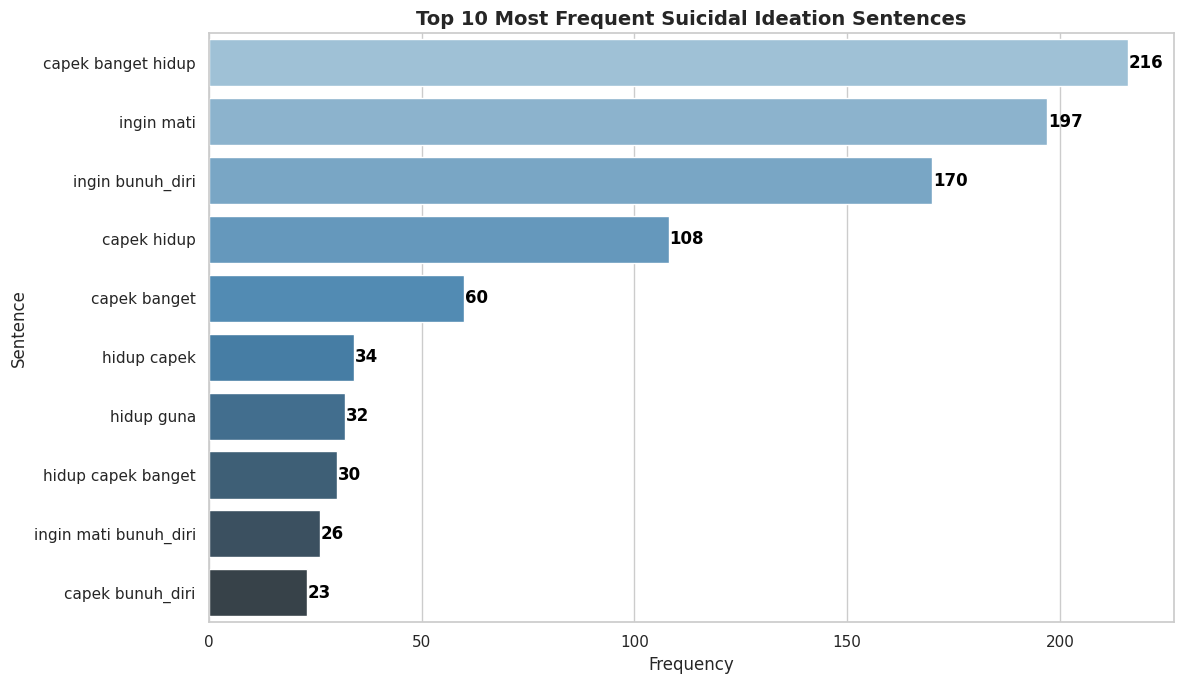

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

top_sentence= df['full_text'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")

ax = sns.barplot(
    x=top_sentence.values,
    y=top_sentence.index,
    palette="Blues_d"
)

for i, v in enumerate(top_sentence.values):
    ax.text(v + 0.2, i, str(v), color='black', va='center', fontweight='bold')

plt.title('Top 10 Most Frequent Suicidal Ideation Sentences', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Sentence', fontsize=12)
plt.tight_layout()
plt.show()


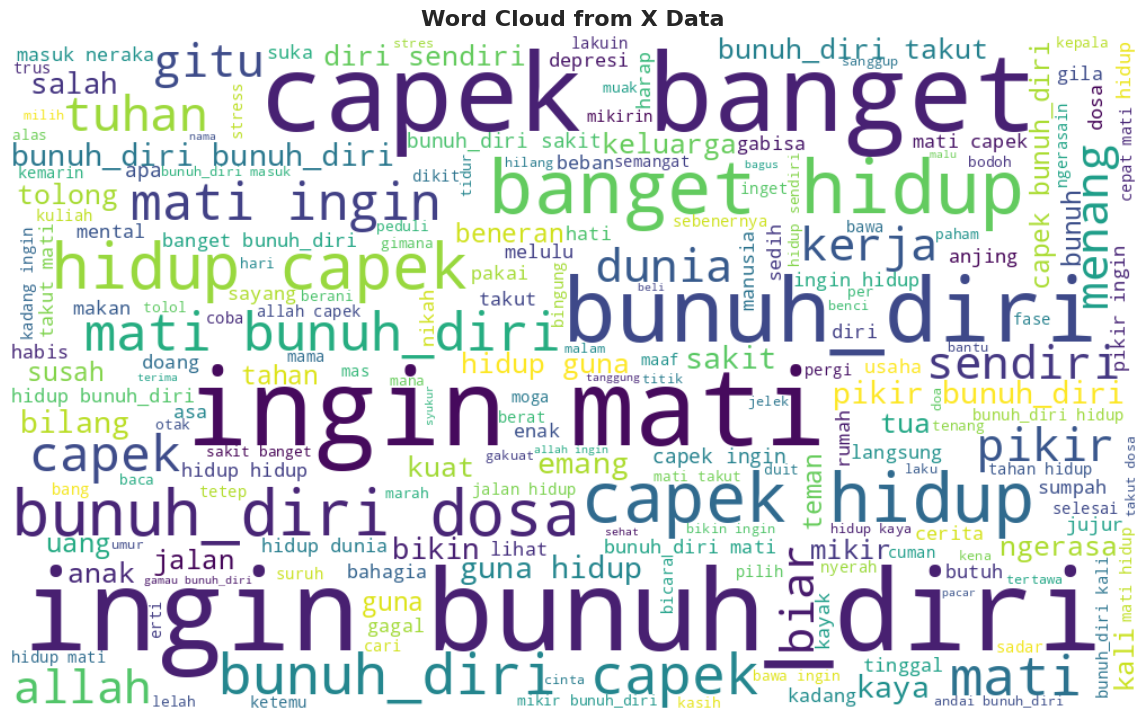

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(df['full_text'])

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='white',
    colormap='viridis',
    max_words=200,
    contour_color='steelblue',
    contour_width=2,
    random_state=42
).generate(all_text)


plt.figure(figsize=(12, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud from X Data', fontsize=16, fontweight='bold')
plt.tight_layout(pad=0)
plt.show()


In [24]:
df['full_text'] = df.to_csv('/content/drive/MyDrive/Skripsi/suicidal ideation data.csv', index=False)

In [25]:
df.head(5)

,full_text
0,None
1,None
2,None
3,None
4,None


# **Association Rules Mining**

In [26]:
dataset = '/content/drive/MyDrive/Skripsi/data skripsi clean.csv'
df = pd.read_csv(dataset, encoding='latin1')
df.head(5)

,full_text
0,ingin bunuh_diri
1,bunuh_diri takut dosa serba salah
2,bunuh_diri jamin tiket fast track surga hidup ...
3,ringan banget tangan nyuruh bunuh_diri
4,what bunuh_diri kuat sumpah


In [27]:
df.shape

(12369, 1)

In [28]:
transactions = df['full_text'].apply(lambda x: x.split()).tolist()

In [29]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(df_encoded.head())

    abai   abis  abnormal  about  abrek  abrik  absurd    abu  abuse  abusive  \
0  False  False     False  False  False  False   False  False  False    False   
1  False  False     False  False  False  False   False  False  False    False   
2  False  False     False  False  False  False   False  False  False    False   
3  False  False     False  False  False  False   False  False  False    False   
4  False  False     False  False  False  False   False  False  False    False   

   ...  yapping  yasudahlah  yatim  yatuhan  yauda    yes  yoongi    you  \
0  ...    False       False  False    False  False  False   False  False   
1  ...    False       False  False    False  False  False   False  False   
2  ...    False       False  False    False  False  False   False  False   
3  ...    False       False  False    False  False  False   False  False   
4  ...    False       False  False    False  False  False   False  False   

   young   zina  
0  False  False  
1  False  False  
2 

In [30]:
df_encoded.head()
df_encoded.shape


(12369, 5276)

In [31]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets_apriori = apriori(df_encoded, min_support=0.04, use_colnames=True)

rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.6)

rules_apriori_sorted = rules_apriori.sort_values(by='lift', ascending=False)
print(rules_apriori_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

             antecedents   consequents   support  confidence      lift
7                 (guna)       (hidup)  0.069529    0.971751  2.787475
11       (hidup, banget)       (capek)  0.105101    0.844704  2.212185
0               (banget)       (capek)  0.167596    0.700338  1.834105
12       (capek, banget)       (hidup)  0.105101    0.627110  1.798870
16    (bunuh_diri, mati)       (ingin)  0.096855    0.637573  1.736271
8                 (mati)       (ingin)  0.195489    0.629687  1.714796
9   (bunuh_diri, banget)       (capek)  0.074541    0.609788  1.596966
6                (hidup)       (capek)  0.211982    0.608071  1.592468
1                 (dosa)  (bunuh_diri)  0.066214    0.939220  1.514038
4                (sakit)  (bunuh_diri)  0.049964    0.861925  1.389437
3                (pikir)  (bunuh_diri)  0.051419    0.830287  1.338436
5                (takut)  (bunuh_diri)  0.048832    0.819539  1.321110
13        (ingin, capek)  (bunuh_diri)  0.071954    0.770563  1.242160
14    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

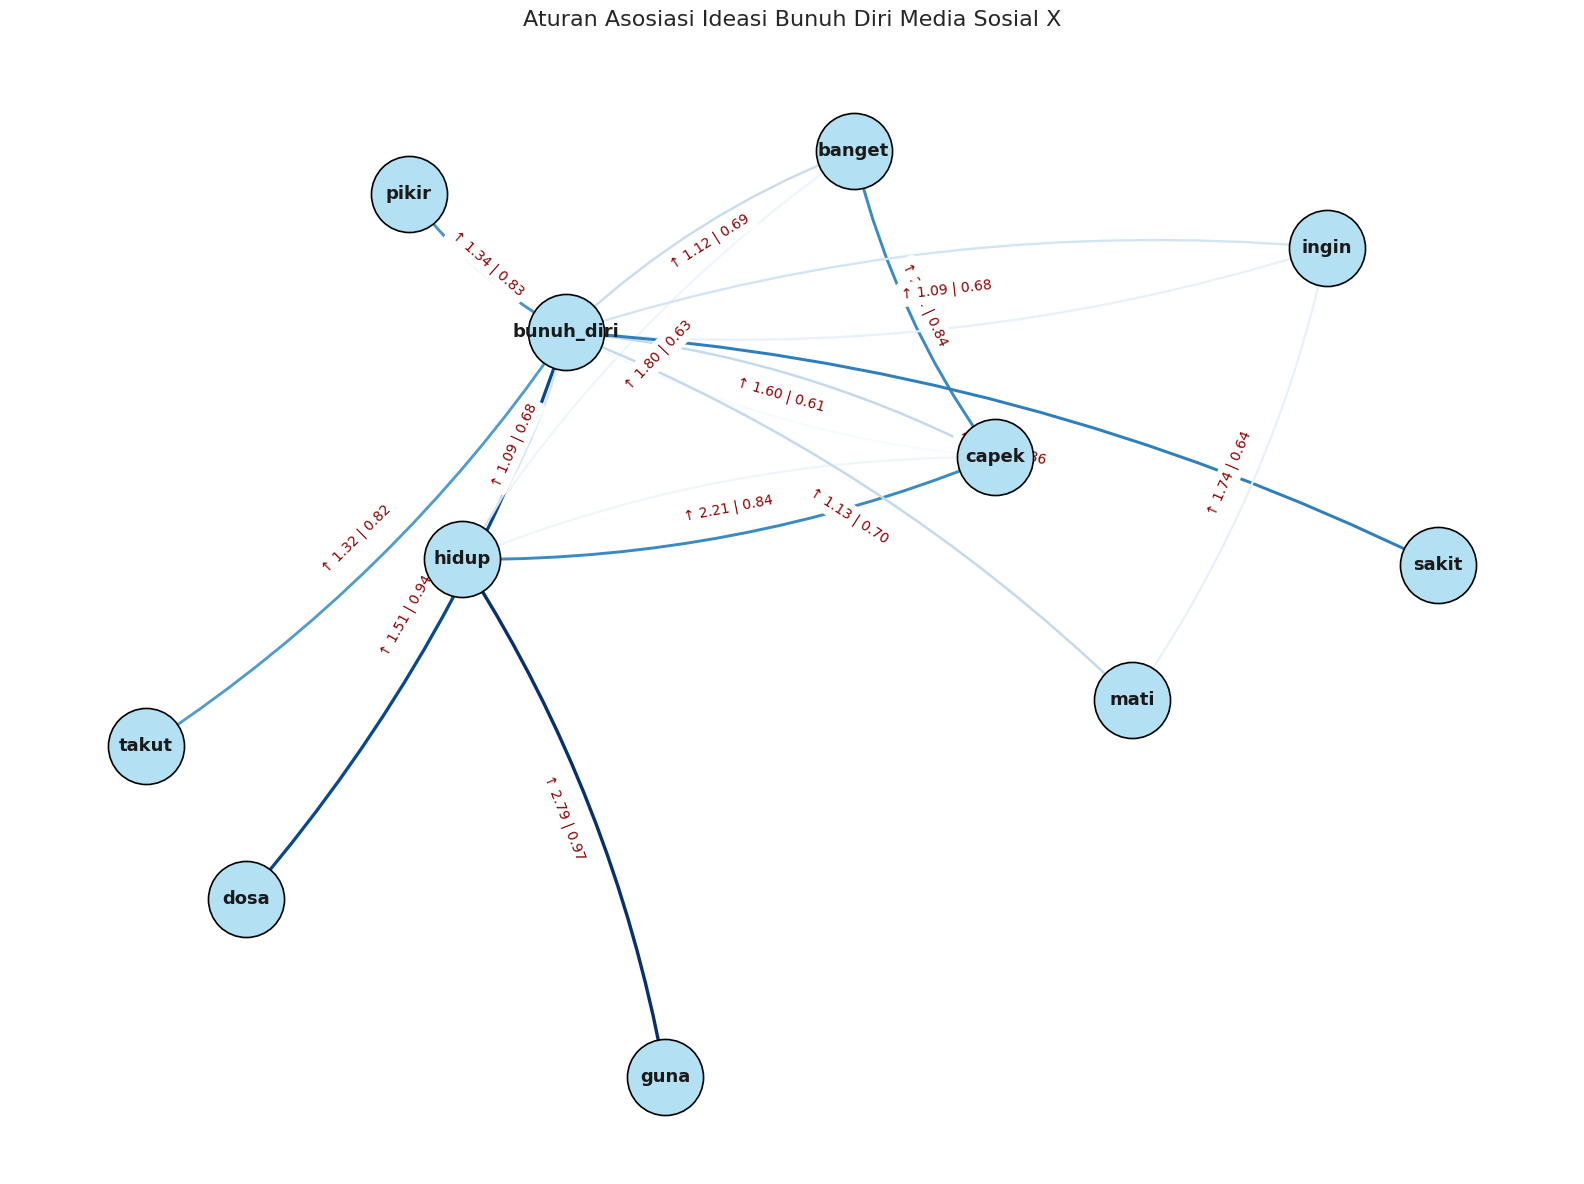

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for _, row in rules_apriori.iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent,
                       weight=row['confidence'],
                       lift=row['lift'],
                       support=row['support'])

pos = nx.spring_layout(G, seed=42, k=1.2)


edges = G.edges(data=True)
weights = [d['weight'] * 2.5 for _, _, d in edges]
colors = [d['weight'] for _, _, d in edges]


fig, ax = plt.subplots(figsize=(16, 12))


nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color='#b3e0f2',
    node_size=3000,
    edgecolors='black',
    linewidths=1.2
)


nx.draw_networkx_edges(
    G, pos, ax=ax,
    edgelist=edges,
    width=weights,
    edge_color=colors,
    edge_cmap=plt.cm.Blues,
    arrows=True,
    arrowsize=20,
    arrowstyle='-|>',
    connectionstyle='arc3,rad=0.1'
)

nx.draw_networkx_labels(
    G, pos, ax=ax,
    font_size=13,
    font_weight='bold'
)

edge_labels = {(u, v): f"↑ {d['lift']:.2f} | {d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels,
    font_size=10,
    font_color='darkred',
    ax=ax
)
ax.set_title("Aturan Asosiasi Ideasi Bunuh Diri Media Sosial X", fontsize=16, pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()


In [33]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Jalankan FP-Growth
frequent_itemsets_fpgrowth = fpgrowth(df_encoded, min_support=0.04, use_colnames=True)

rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=0.6)

rules_fpgrowth_sorted = rules_fpgrowth.sort_values(by='lift', ascending=False)
print(rules_fpgrowth_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']])



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

             antecedents   consequents   support  confidence      lift
16                (guna)       (hidup)  0.069529    0.971751  2.787475
8        (hidup, banget)       (capek)  0.105101    0.844704  2.212185
6               (banget)       (capek)  0.167596    0.700338  1.834105
9        (capek, banget)       (hidup)  0.105101    0.627110  1.798870
12    (bunuh_diri, mati)       (ingin)  0.096855    0.637573  1.736271
11                (mati)       (ingin)  0.195489    0.629687  1.714796
7   (bunuh_diri, banget)       (capek)  0.074541    0.609788  1.596966
4                (hidup)       (capek)  0.211982    0.608071  1.592468
2                 (dosa)  (bunuh_diri)  0.066214    0.939220  1.514038
15               (sakit)  (bunuh_diri)  0.049964    0.861925  1.389437
14               (pikir)  (bunuh_diri)  0.051419    0.830287  1.338436
3                (takut)  (bunuh_diri)  0.048832    0.819539  1.321110
1         (ingin, capek)  (bunuh_diri)  0.071954    0.770563  1.242160
13    

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [34]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets_fpgrowth = fpgrowth(df_encoded, min_support=0.04, use_colnames=True)
frequent_itemsets_fpgrowth['length'] = frequent_itemsets_fpgrowth['itemsets'].apply(lambda x: len(x))
print(frequent_itemsets_fpgrowth)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

     support                     itemsets  length
0   0.620341                 (bunuh_diri)       1
1   0.367208                      (ingin)       1
2   0.070499                       (dosa)       1
3   0.059584                      (takut)       1
4   0.348613                      (hidup)       1
5   0.239308                     (banget)       1
6   0.310454                       (mati)       1
7   0.046487                      (dunia)       1
8   0.054249                    (sendiri)       1
9   0.061929                      (pikir)       1
10  0.041636                      (allah)       1
11  0.381842                      (capek)       1
12  0.043011                       (diri)       1
13  0.057967                      (sakit)       1
14  0.040424                     (menang)       1
15  0.071550                       (guna)       1
16  0.252729          (bunuh_diri, ingin)       2
17  0.093379               (ingin, capek)       2
18  0.071954   (bunuh_diri, ingin, capek)       3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

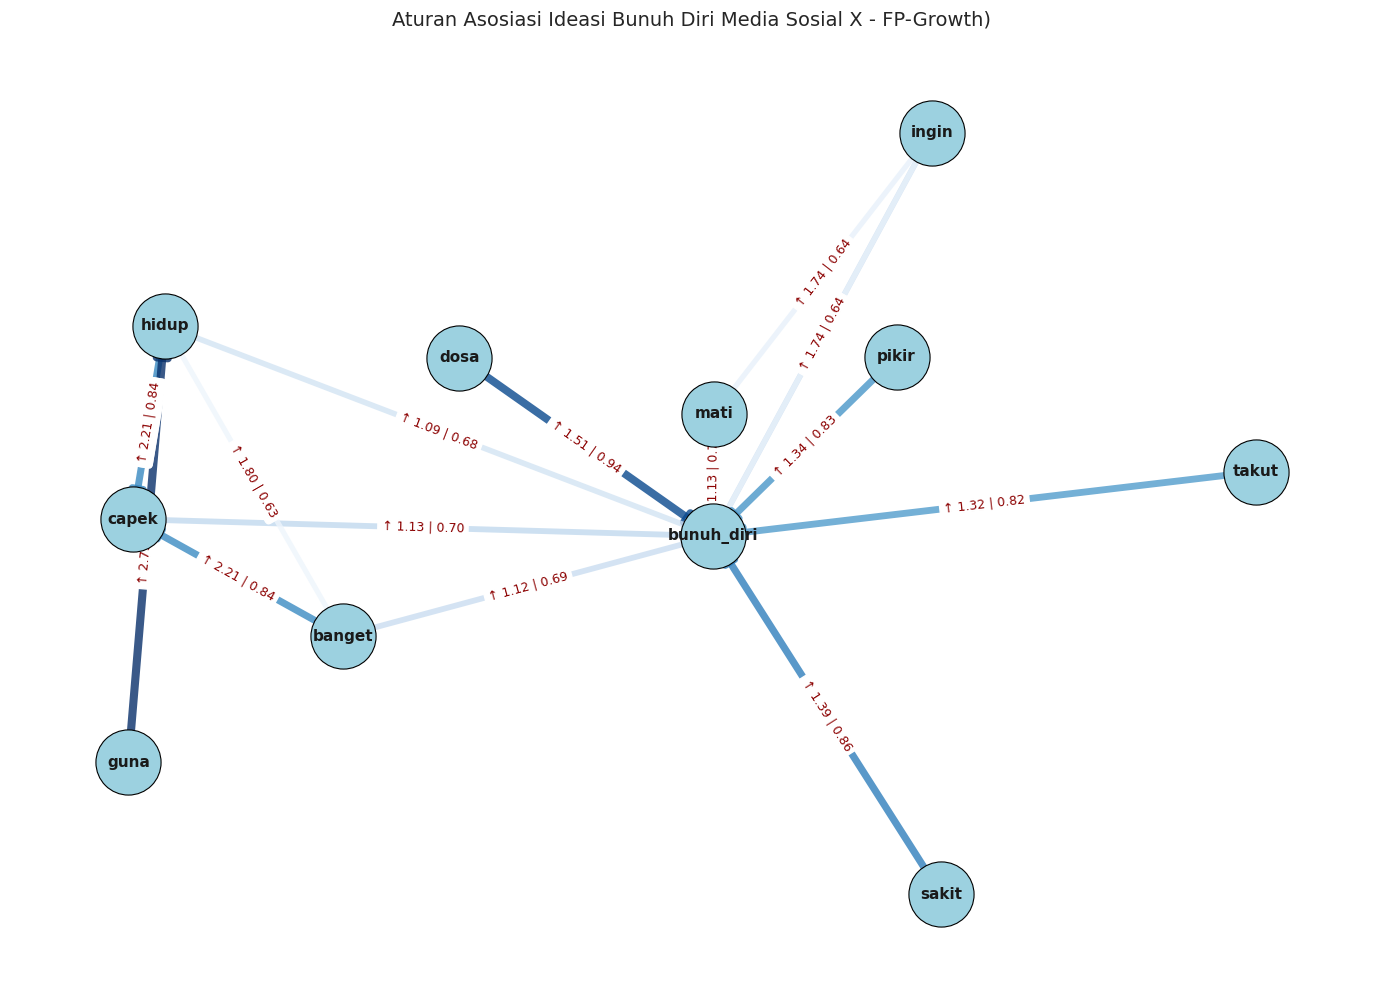

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

G = nx.DiGraph()

for _, row in rules_fpgrowth.iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent,
                       weight=row['confidence'],
                       lift=row['lift'],
                       support=row['support'])

pos = nx.spring_layout(G, seed=42, k=0.7)

edges = G.edges(data=True)
weights = [edge[2]['weight'] * 6 for edge in edges]
colors = [edge[2]['weight'] for edge in edges]

# Buat figure
plt.figure(figsize=(14, 10))
nodes = nx.draw_networkx_nodes(G, pos, node_color='#9cd1e0', node_size=2200, edgecolors='black', linewidths=0.8)
edges_drawn = nx.draw_networkx_edges(G, pos, width=weights, edge_color=colors, edge_cmap=plt.cm.Blues, alpha=0.8, arrows=True, arrowsize=20)

nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

edge_labels = {(u, v): f"↑ {d['lift']:.2f} | {d['weight']:.2f}" for u, v, d in edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='darkred')


plt.title("Aturan Asosiasi Ideasi Bunuh Diri Media Sosial X - FP-Growth)", fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


In [36]:
# Kolom kombinasi untuk identifikasi aturan unik
rules_apriori['rule_str'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(sorted(x))) + ' -> ' + \
                            rules_apriori['consequents'].apply(lambda x: ', '.join(sorted(x)))

rules_fpgrowth['rule_str'] = rules_fpgrowth['antecedents'].apply(lambda x: ', '.join(sorted(x))) + ' -> ' + \
                             rules_fpgrowth['consequents'].apply(lambda x: ', '.join(sorted(x)))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [37]:
only_apriori = set(rules_apriori['rule_str']) - set(rules_fpgrowth['rule_str'])
print("Aturan yang hanya ada di Apriori:")
for r in only_apriori:
    print(r)


Aturan yang hanya ada di Apriori:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [38]:
only_fpgrowth = set(rules_fpgrowth['rule_str']) - set(rules_apriori['rule_str'])
print("Aturan yang hanya ada di FP-Growth:")
for r in only_fpgrowth:
    print(r)


Aturan yang hanya ada di FP-Growth:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [39]:
common_rules = set(rules_apriori['rule_str']) & set(rules_fpgrowth['rule_str'])
print("Aturan yang muncul di kedua metode:")
for r in common_rules:
    print(r)


Aturan yang muncul di kedua metode:
banget, bunuh_diri -> capek
guna -> hidup
hidup -> capek
banget, hidup -> capek
capek, ingin -> bunuh_diri
capek, mati -> bunuh_diri
sakit -> bunuh_diri
banget -> capek
takut -> bunuh_diri
pikir -> bunuh_diri
bunuh_diri, mati -> ingin
ingin -> bunuh_diri
banget, ingin -> bunuh_diri
dosa -> bunuh_diri
banget, capek -> hidup
hidup, ingin -> bunuh_diri
mati -> ingin


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

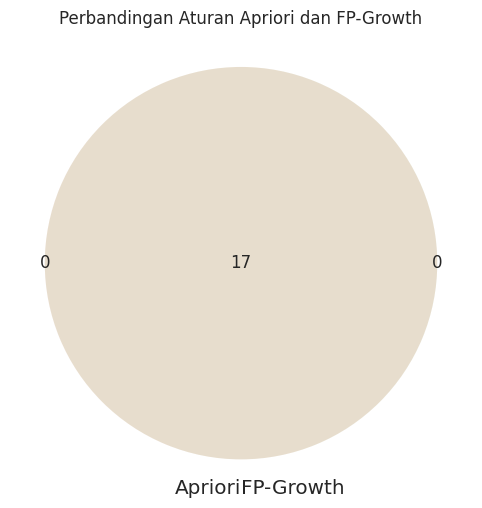

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [40]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Buat set aturan (sebagai string)
apriori_rules = set(rules_apriori['rule_str'])
fpgrowth_rules = set(rules_fpgrowth['rule_str'])

# Buat Venn diagram
plt.figure(figsize=(8, 6))
venn2([apriori_rules, fpgrowth_rules], set_labels=('Apriori', 'FP-Growth'))
plt.title("Perbandingan Aturan Apriori dan FP-Growth")
plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

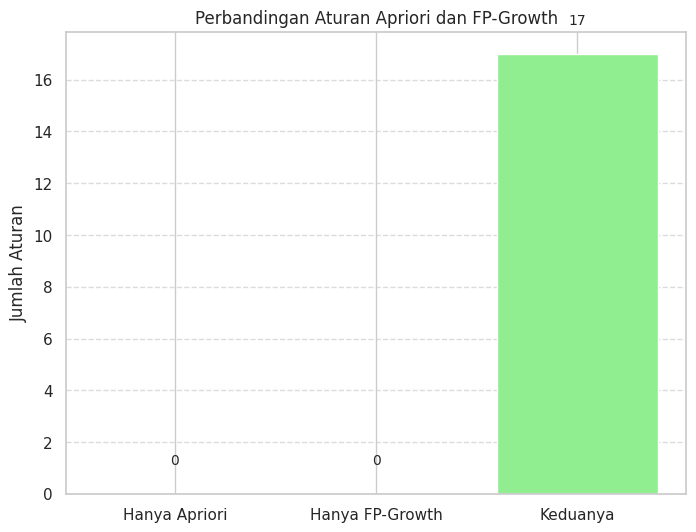

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [41]:
import matplotlib.pyplot as plt

# Hitung jumlah
only_apriori = len(apriori_rules - fpgrowth_rules)
only_fpgrowth = len(fpgrowth_rules - apriori_rules)
common = len(apriori_rules & fpgrowth_rules)

# Plot batang
labels = ['Hanya Apriori', 'Hanya FP-Growth', 'Keduanya']
counts = [only_apriori, only_fpgrowth, common]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['salmon', 'skyblue', 'lightgreen'])
plt.title('Perbandingan Aturan Apriori dan FP-Growth')
plt.ylabel('Jumlah Aturan')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label jumlah
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(height),
             ha='center', va='bottom', fontsize=10)

plt.show()


In [42]:
# Buat rule_str untuk join
rules_apriori['rule_str'] = rules_apriori['antecedents'].apply(lambda x: ', '.join(sorted(x))) + ' -> ' + \
                    rules_apriori['consequents'].apply(lambda x: ', '.join(sorted(x)))

rules_fpgrowth['rule_str'] = rules_fpgrowth['antecedents'].apply(lambda x: ', '.join(sorted(x))) + ' -> ' + \
                      rules_fpgrowth['consequents'].apply(lambda x: ', '.join(sorted(x)))

# Gabungkan berdasarkan rule_str
merged_rules = pd.merge(rules_apriori[['rule_str', 'confidence', 'lift']],
                        rules_fpgrowth[['rule_str', 'confidence', 'lift']],
                        on='rule_str',
                        suffixes=('_apriori', '_fpgrowth'))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

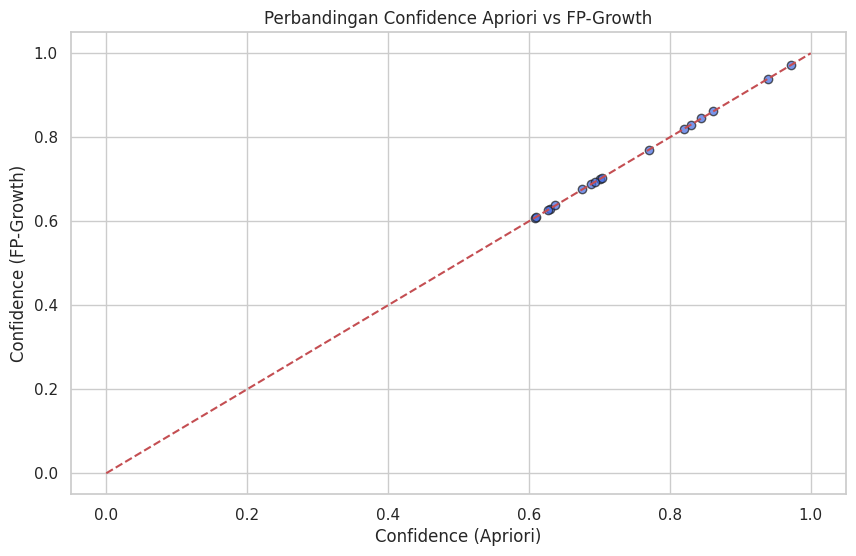

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

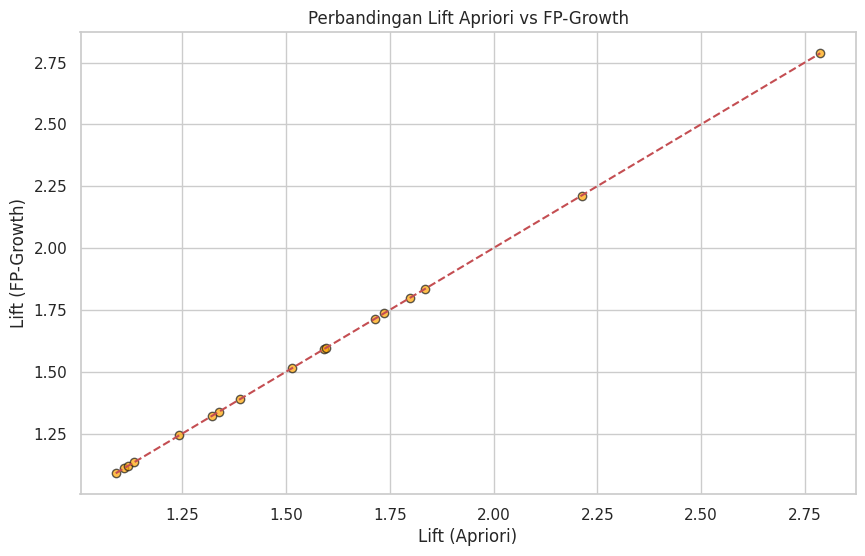

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(merged_rules['confidence_apriori'], merged_rules['confidence_fpgrowth'],
            alpha=0.7, color='royalblue', edgecolor='k')
plt.plot([0, 1], [0, 1], 'r--')  # garis diagonal referensi
plt.xlabel('Confidence (Apriori)')
plt.ylabel('Confidence (FP-Growth)')
plt.title('Perbandingan Confidence Apriori vs FP-Growth')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(merged_rules['lift_apriori'], merged_rules['lift_fpgrowth'],
            alpha=0.7, color='orange', edgecolor='k')
plt.plot([merged_rules['lift_apriori'].min(), merged_rules['lift_apriori'].max()],
         [merged_rules['lift_apriori'].min(), merged_rules['lift_apriori'].max()],
         'r--')
plt.xlabel('Lift (Apriori)')
plt.ylabel('Lift (FP-Growth)')
plt.title('Perbandingan Lift Apriori vs FP-Growth')
plt.grid(True)
plt.show()


In [44]:
import time
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# --- APRIORI ---
start_apriori = time.time()

frequent_itemsets_apriori = apriori(df_encoded, min_support=0.04, use_colnames=True)
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.7)

end_apriori = time.time()
time_apriori = end_apriori - start_apriori

print(f"Waktu eksekusi Apriori: {time_apriori:.4f} detik")


# --- FP-GROWTH ---
start_fpgrowth = time.time()

frequent_itemsets_fp = fpgrowth(df_encoded, min_support=0.04, use_colnames=True)
rules_fp = association_rules(frequent_itemsets_fp, metric="confidence", min_threshold=0.7)

end_fpgrowth = time.time()
time_fpgrowth = end_fpgrowth - start_fpgrowth

print(f"Waktu eksekusi FP-Growth: {time_fpgrowth:.4f} detik")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Waktu eksekusi Apriori: 0.2552 detik


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

Waktu eksekusi FP-Growth: 6.6827 detik


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [45]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

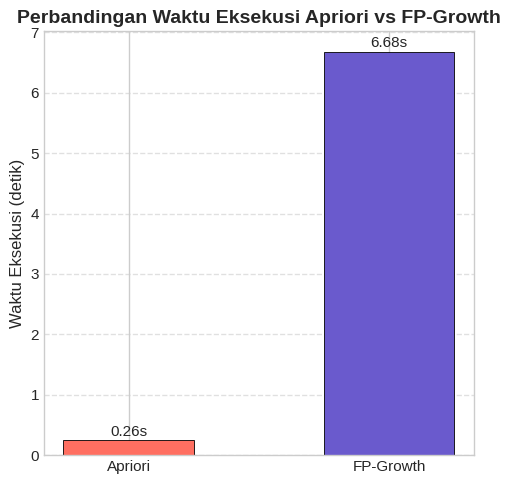

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [46]:
import matplotlib.pyplot as plt

algorithms = ['Apriori', 'FP-Growth']
times = [time_apriori, time_fpgrowth]

plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(5, 5))

colors = ['#FF6F61', '#6A5ACD']

bars = plt.bar(algorithms, times, color=colors, width=0.5, edgecolor='black', linewidth=0.6)

plt.title('Perbandingan Waktu Eksekusi Apriori vs FP-Growth', fontsize=14, fontweight='bold')
plt.ylabel('Waktu Eksekusi (detik)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}s',
             ha='center', va='bottom', fontsize=11, fontweight='medium')

plt.tight_layout()
plt.show()
